In [1]:
import math
import numpy as np

sequences = {
    "S1": "ATTGCCATT",
    "S2": "ATGGCCATT",
    "S3": "ATCCAATTTT",
    "S4": "ATCTTCTT",
    "S5": "ACTGACC"
}

def needleman_wunsch(seq1, seq2, match=1, mismatch=-1, gap=-1):
    n, m = len(seq1), len(seq2)
    score = np.zeros((n + 1, m + 1))

    for i in range(n + 1):
        score[i][0] = i * gap
    for j in range(m + 1):
        score[0][j] = j * gap

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = score[i - 1][j - 1] + (match if seq1[i - 1] == seq2[j - 1] else mismatch)
            delete = score[i - 1][j] + gap
            insert = score[i][j - 1] + gap
            score[i][j] = max(diag, delete, insert)

    # Traceback
    align1, align2 = [], []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and score[i][j] == score[i - 1][j - 1] + (match if seq1[i - 1] == seq2[j - 1] else mismatch):
            align1.append(seq1[i - 1])
            align2.append(seq2[j - 1])
            i -= 1
            j -= 1
        elif i > 0 and score[i][j] == score[i - 1][j] + gap:
            align1.append(seq1[i - 1])
            align2.append('-')
            i -= 1
        else:
            align1.append('-')
            align2.append(seq2[j - 1])
            j -= 1

    return "".join(reversed(align1)), "".join(reversed(align2))

def jukes_cantor_distance(seq1, seq2):
    if seq1 == seq2:
        return 0.0

    if len(seq1) != len(seq2):
        a1, a2 = needleman_wunsch(seq1, seq2)
    else:
        a1, a2 = seq1, seq2

    total_len = len(a1)
    differences = sum(1 for c1, c2 in zip(a1, a2) if c1 != c2)

    p = differences / total_len
    if p >= 0.75:
        raise ValueError(f"Saturación mutacional excesiva (p={p:.3f} >= 0.75)")

    d_jc = -0.75 * math.log(1.0 - (4.0 / 3.0) * p)
    return round(d_jc, 4)

#matriz 5x5
labels = list(sequences.keys())
n = len(labels)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        d = jukes_cantor_distance(sequences[labels[i]], sequences[labels[j]])
        dist_matrix[i][j] = d
        dist_matrix[j][i] = d

print("Matriz de Distancias (Jukes-Cantor):")
print(f"{'':>6}" + "".join(f"{lbl:>8}" for lbl in labels))
for i, lbl in enumerate(labels):
    row_str = "".join(f"{dist_matrix[i][j]:8.4f}" for j in range(n))
    print(f"{lbl:>6}{row_str}")

Matriz de Distancias (Jukes-Cantor):
            S1      S2      S3      S4      S5
    S1  0.0000  0.1203  0.6082  0.5716  0.8240
    S2  0.1203  0.0000  0.6082  0.6735  0.8240
    S3  0.6082  0.6082  0.0000  0.4975  2.0310
    S4  0.5716  0.6735  0.4975  0.0000  1.0124
    S5  0.8240  0.8240  2.0310  1.0124  0.0000


In [2]:
class UPGMANode:
    def __init__(self, name, height=0.0, left=None, right=None, branch_len=0.0):
        self.name = name
        self.height = height
        self.left = left
        self.right = right
        self.branch_len = branch_len

    def to_newick(self):
        if self.left is None and self.right is None:
            return f"{self.name}:{self.branch_len:.4f}"
        return f"({self.left.to_newick()},{self.right.to_newick()}):{self.branch_len:.4f}"

def run_upgma(dist_mat, taxon_names):
    clusters = {i: {"node": UPGMANode(taxon_names[i], height=0.0), "size": 1} for i in range(len(taxon_names))}

    n = len(taxon_names)
    matrix = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[(i, j)] = dist_mat[i][j]

    active_keys = list(clusters.keys())
    next_id = n

    print("--- ITERACIONES UPGMA ---")
    iteration = 1
    while len(active_keys) > 1:
        # 1. Encontrar el par con menor distancia
        min_dist = float('inf')
        pair_to_merge = None
        for idx1 in range(len(active_keys)):
            for idx2 in range(idx1 + 1, len(active_keys)):
                k1, k2 = active_keys[idx1], active_keys[idx2]
                d = matrix[(k1, k2)]
                if d < min_dist:
                    min_dist = d
                    pair_to_merge = (k1, k2)

        k1, k2 = pair_to_merge
        node1 = clusters[k1]["node"]
        node2 = clusters[k2]["node"]
        size1 = clusters[k1]["size"]
        size2 = clusters[k2]["size"]

        # 2. Calcular altura y longitud de ramas
        node_height = min_dist / 2.0
        node1.branch_len = max(0.0, node_height - node1.height)
        node2.branch_len = max(0.0, node_height - node2.height)

        merged_name = f"({node1.name},{node2.name})"
        new_node = UPGMANode(name=merged_name, height=node_height, left=node1, right=node2)
        new_size = size1 + size2

        print(f"Iteración {iteration}: Fusionando {node1.name} y {node2.name} | Distancia = {min_dist:.4f} | Altura = {node_height:.4f}")

        # 3. Calcular distancias hacia los demás clústeres activos
        for other in active_keys:
            if other != k1 and other != k2:
                # Media ponderada aritmética
                d_new = (size1 * matrix[(k1, other)] + size2 * matrix[(k2, other)]) / new_size
                matrix[(next_id, other)] = d_new
                matrix[(other, next_id)] = d_new

        # 4. Actualizar clústeres activos
        active_keys.remove(k1)
        active_keys.remove(k2)
        active_keys.append(next_id)
        clusters[next_id] = {"node": new_node, "size": new_size}
        next_id += 1
        iteration += 1

    root_node = clusters[active_keys[0]]["node"]
    newick_str = f"({root_node.left.to_newick()},{root_node.right.to_newick()});"
    return root_node, newick_str

upgma_root, upgma_newick = run_upgma(dist_matrix, labels)
print("\nÁrbol UPGMA en formato Newick:")
print(upgma_newick)

--- ITERACIONES UPGMA ---
Iteración 1: Fusionando S1 y S2 | Distancia = 0.1203 | Altura = 0.0602
Iteración 2: Fusionando S3 y S4 | Distancia = 0.4975 | Altura = 0.2487
Iteración 3: Fusionando (S1,S2) y (S3,S4) | Distancia = 0.6154 | Altura = 0.3077
Iteración 4: Fusionando S5 y ((S1,S2),(S3,S4)) | Distancia = 1.1728 | Altura = 0.5864

Árbol UPGMA en formato Newick:
(S5:0.5864,((S1:0.0602,S2:0.0602):0.2475,(S3:0.2487,S4:0.2487):0.0589):0.2787);


In [3]:
class NJNode:
    def __init__(self, name, left=None, right=None, branch_len=0.0):
        self.name = name
        self.left = left
        self.right = right
        self.branch_len = branch_len

    def to_newick(self):
        if self.left is None and self.right is None:
            return f"{self.name}:{self.branch_len:.4f}"
        return f"({self.left.to_newick()},{self.right.to_newick()}):{self.branch_len:.4f}"

def run_neighbor_joining(dist_mat, taxon_names):
    # Inicialización de nodos y matriz de trabajo
    nodes = {i: NJNode(taxon_names[i]) for i in range(len(taxon_names))}
    active_keys = list(nodes.keys())

    n = len(taxon_names)
    matrix = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[(i, j)] = dist_mat[i][j]

    next_id = n
    iteration = 1
    print("--- ITERACIONES NEIGHBOR JOINING ---")

    while len(active_keys) > 2:
        m = len(active_keys)

        # 1. Calcular u_i para cada nodo activo: sum(M_ik) / (m - 2)
        u = {}
        for i in active_keys:
            u[i] = sum(matrix[(i, k)] for k in active_keys if k != i) / (m - 2)

        # 2. Encontrar el par (i, j) que minimiza Q_ij = M_ij - u_i - u_j
        min_q = float('inf')
        best_pair = None
        for idx1 in range(m):
            for idx2 in range(idx1 + 1, m):
                i = active_keys[idx1]
                j = active_keys[idx2]
                q_val = matrix[(i, j)] - u[i] - u[j]
                if q_val < min_q:
                    min_q = q_val
                    best_pair = (i, j)

        i, j = best_pair
        node_i = nodes[i]
        node_j = nodes[j]

        # 3. Calcular longitudes de rama al nuevo nodo
        d_i_new = 0.5 * (matrix[(i, j)] + u[i] - u[j])
        d_j_new = 0.5 * (matrix[(i, j)] + u[j] - u[i])

        node_i.branch_len = d_i_new
        node_j.branch_len = d_j_new

        merged_name = f"({node_i.name},{node_j.name})"
        new_node = NJNode(name=merged_name, left=node_i, right=node_j)

        print(f"Iteración {iteration} (n={m}):")
        print(f"  Pares fusionados: {node_i.name} y {node_j.name} (Q_min = {min_q:.4f})")
        print(f"  Longitud rama {node_i.name} -> {new_node.name}: {d_i_new:.4f}")
        print(f"  Longitud rama {node_j.name} -> {new_node.name}: {d_j_new:.4f}")

        # 4. Actualizar distancias del nuevo nodo hacia los demás
        for k in active_keys:
            if k != i and k != j:
                d_new_k = 0.5 * (matrix[(i, k)] + matrix[(j, k)] - matrix[(i, j)])
                matrix[(next_id, k)] = d_new_k
                matrix[(k, next_id)] = d_new_k

        # 5. Reemplazar i y j por next_id
        active_keys.remove(i)
        active_keys.remove(j)
        active_keys.append(next_id)
        nodes[next_id] = new_node
        next_id += 1
        iteration += 1

    # Caso base cuando quedan exactamente 2 nodos (rama final)
    k1, k2 = active_keys[0], active_keys[1]
    final_dist = matrix[(k1, k2)]
    print(f"\nCaso Final (n=2): Conectando {nodes[k1].name} y {nodes[k2].name} con distancia = {final_dist:.4f}")

    # En un árbol sin raíz de 2 subárboles, asignamos la distancia residual
    nodes[k1].branch_len = final_dist / 2.0
    nodes[k2].branch_len = final_dist / 2.0
    nj_newick = f"({nodes[k1].to_newick()},{nodes[k2].to_newick()});"

    return nodes, nj_newick

# Ejecutar NJ sobre la matriz calculada en el Paso 1
nj_nodes, nj_newick = run_neighbor_joining(dist_matrix, labels)
print("\nÁrbol Neighbor Joining en formato Newick:")
print(nj_newick)

--- ITERACIONES NEIGHBOR JOINING ---
Iteración 1 (n=5):
  Pares fusionados: S3 y S4 (Q_min = -1.6691)
  Longitud rama S3 -> (S3,S4): 0.4137
  Longitud rama S4 -> (S3,S4): 0.0838
Iteración 2 (n=4):
  Pares fusionados: S1 y (S3,S4) (Q_min = -1.3047)
  Longitud rama S1 -> (S1,(S3,S4)): -0.0096
  Longitud rama (S3,S4) -> (S1,(S3,S4)): 0.3508
Iteración 3 (n=3):
  Pares fusionados: S2 y S5 (Q_min = -1.7875)
  Longitud rama S2 -> (S2,S5): 0.0159
  Longitud rama S5 -> (S2,S5): 0.8081

Caso Final (n=2): Conectando (S1,(S3,S4)) y (S2,S5) con distancia = 0.0698

Árbol Neighbor Joining en formato Newick:
((S1:-0.0096,(S3:0.4137,S4:0.0838):0.3508):0.0349,(S2:0.0159,S5:0.8081):0.0349);


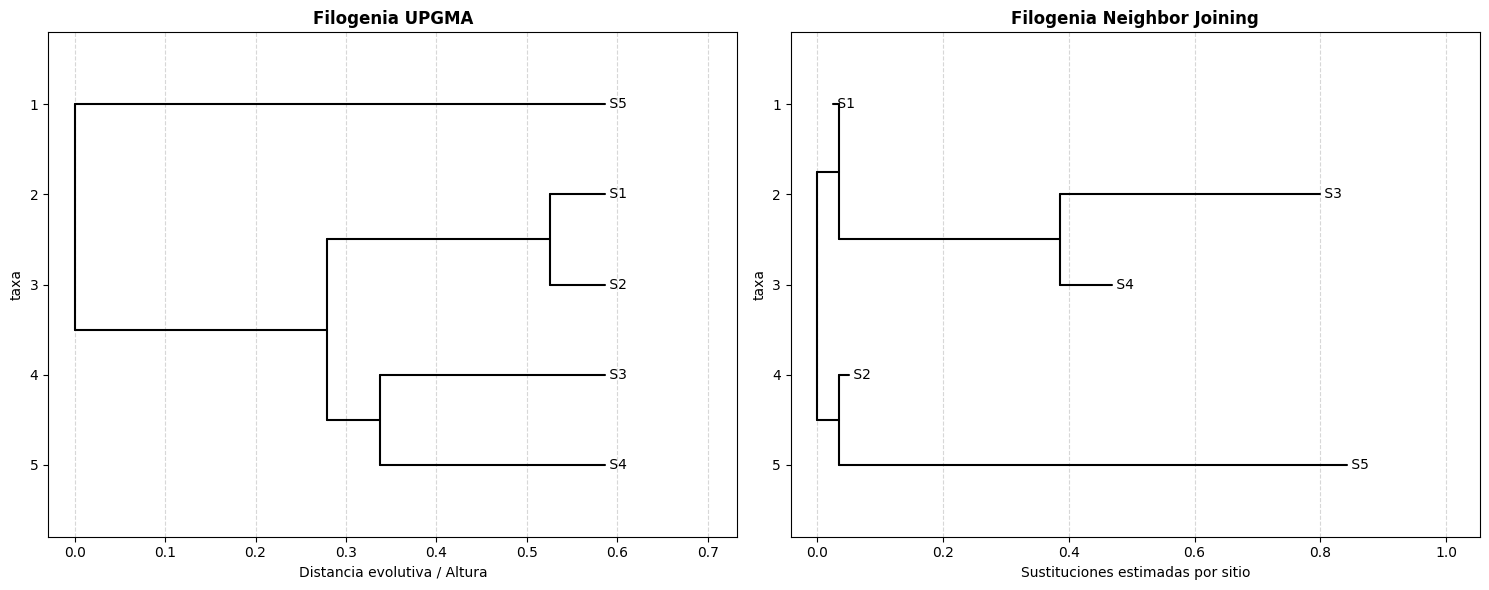


--- Topología ASCII: UPGMA ---
  _________________________________________________________________________ S5
 |
_|                                                                  _______ S1
 |                                   ______________________________|
 |                                  |                              |_______ S2
 |__________________________________|
                                    |       ______________________________ S3
                                    |______|
                                           |______________________________ S4


--- Topología ASCII: Neighbor Joining ---
    , S1
  __|
 |  |                              ____________________________________ S3
 |  |_____________________________|
_|                                |_______ S4
 |
 |  , S2
 |__|
    |______________________________________________________________________ S5



In [5]:
!pip install -q biopython

import io
import matplotlib.pyplot as plt
from Bio import Phylo

tree_upgma_str = upgma_newick
tree_nj_str = nj_newick


tree_upgma = Phylo.read(io.StringIO(tree_upgma_str), "newick")
tree_nj = Phylo.read(io.StringIO(tree_nj_str), "newick")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].set_title("Filogenia UPGMA", fontsize=12, fontweight='bold')
Phylo.draw(tree_upgma, axes=axes[0], do_show=False)
axes[0].set_xlabel("Distancia evolutiva / Altura")
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

axes[1].set_title("Filogenia Neighbor Joining", fontsize=12, fontweight='bold')
Phylo.draw(tree_nj, axes=axes[1], do_show=False)
axes[1].set_xlabel("Sustituciones estimadas por sitio")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("comparativa_arboles_dna.png", dpi=300)
plt.show()

print("\n--- Topología ASCII: UPGMA ---")
Phylo.draw_ascii(tree_upgma)

print("\n--- Topología ASCII: Neighbor Joining ---")
Phylo.draw_ascii(tree_nj)

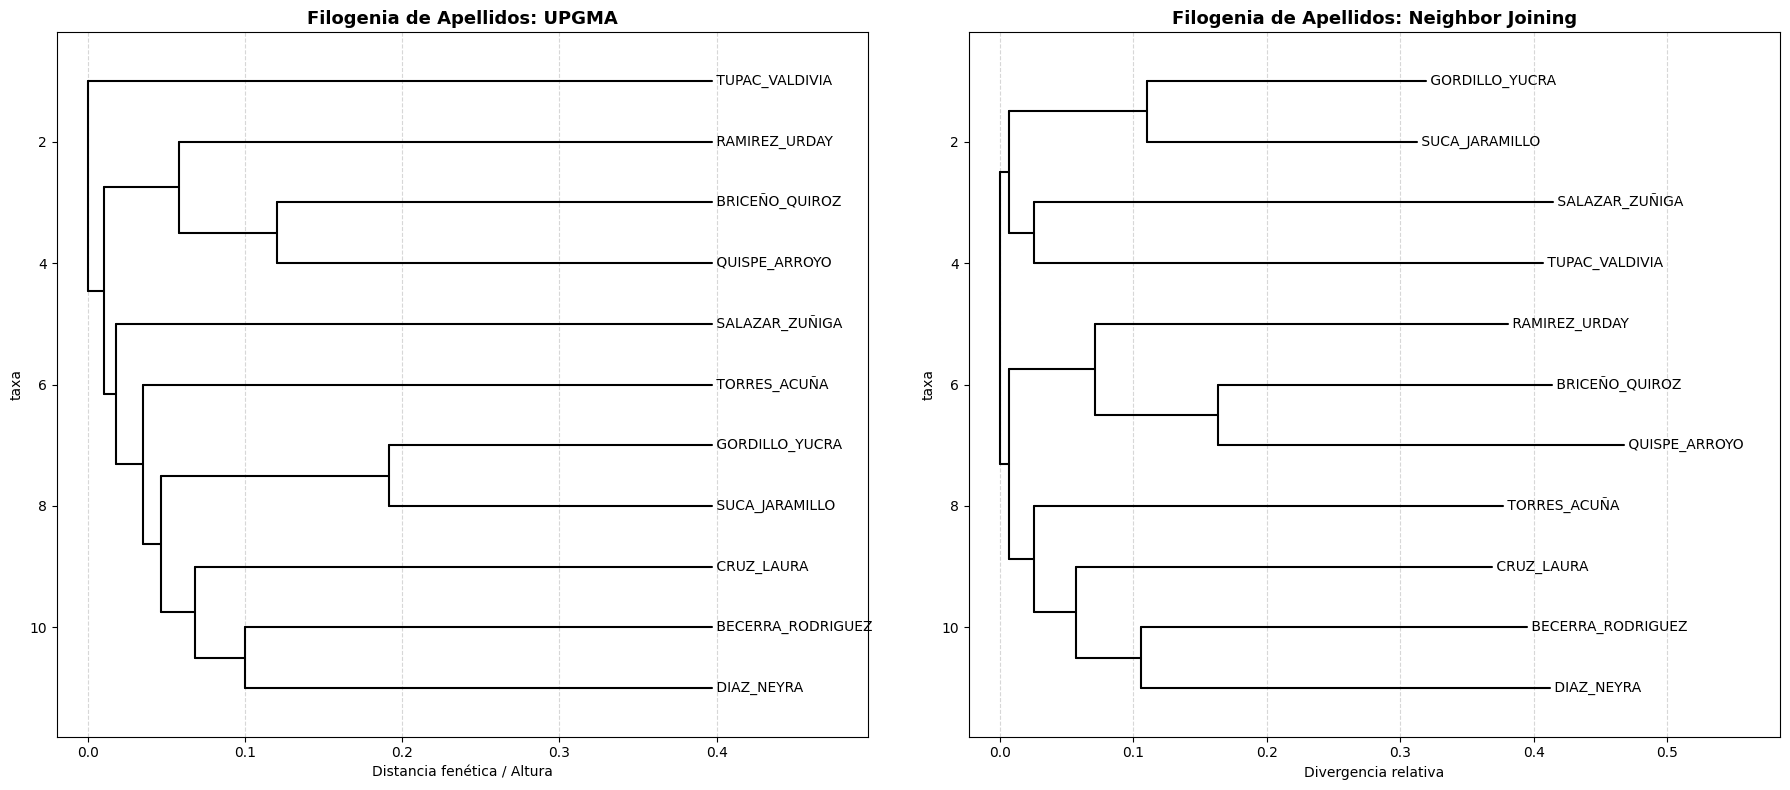


--- NEWICK UPGMA ---
(TUPAC_VALDIVIA:0.3971,((RAMIREZ_URDAY:0.3393,(BRICEÑO_QUIROZ:0.2768,QUISPE_ARROYO:0.2768):0.0625):0.0477,(SALAZAR_ZUÑIGA:0.3793,(TORRES_ACUÑA:0.3622,((GORDILLO_YUCRA:0.2056,SUCA_JARAMILLO:0.2056):0.1452,(CRUZ_LAURA:0.3290,(BECERRA_RODRIGUEZ:0.2976,DIAZ_NEYRA:0.2976):0.0314):0.0218):0.0114):0.0171):0.0078):0.0101);

--- NEWICK NEIGHBOR JOINING ---
(((GORDILLO_YUCRA:0.2088,SUCA_JARAMILLO:0.2023):0.1034,(SALAZAR_ZUÑIGA:0.3891,TUPAC_VALDIVIA:0.3817):0.0185):0.0069,((RAMIREZ_URDAY:0.3093,(BRICEÑO_QUIROZ:0.2497,QUISPE_ARROYO:0.3039):0.0925):0.0643,(TORRES_ACUÑA:0.3509,(CRUZ_LAURA:0.3116,(BECERRA_RODRIGUEZ:0.2887,DIAZ_NEYRA:0.3065):0.0488):0.0314):0.0189):0.0069);


In [6]:
import os
import io
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from Bio import Phylo

FILE_PATH = "data.txt"

def load_data(filepath=FILE_PATH):
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"El archivo '{filepath}' no existe en el directorio de ejecución. "
            "Asegúrate de subirlo o crearlo antes de correr la celda."
        )

    members = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            tokens = line.strip().split()
            if not tokens:
                continue
            if len(tokens) < 2:
                print(f"Advertencia: línea {line_num} ignorada (se requieren al menos 2 apellidos): '{line.strip()}'")
                continue

            paterno = tokens[0]
            materno = tokens[1]
            label = f"{paterno}_{materno}"

            members.append({
                "label": label,
                "paterno": paterno,
                "materno": materno
            })

    if not members:
        raise ValueError(f"El archivo '{filepath}' está vacío o no contiene registros válidos.")

    return members

members = load_data(FILE_PATH)
labels = [m["label"] for m in members]
n = len(labels)


def clean_str(s):
    s = unicodedata.normalize('NFD', s)
    return "".join(c for c in s if unicodedata.category(c) != 'Mn').lower()

def levenshtein_norm(s1, s2):
    s1, s2 = clean_str(s1), clean_str(s2)
    len1, len2 = len(s1), len(s2)
    dp = [[0] * (len2 + 1) for _ in range(len1 + 1)]

    for i in range(len1 + 1):
        dp[i][0] = i
    for j in range(len2 + 1):
        dp[0][j] = j

    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1,
                           dp[i][j - 1] + 1,
                           dp[i - 1][j - 1] + cost)

    return dp[len1][len2] / max(len1, len2, 1)

def surname_distance(p1, p2):
    P1, M1 = p1["paterno"], p1["materno"]
    P2, M2 = p2["paterno"], p2["materno"]

    # Cruces directos y permutados
    d_pp = levenshtein_norm(P1, P2)
    d_mm = levenshtein_norm(M1, M2)
    d_pm = levenshtein_norm(P1, M2)
    d_mp = levenshtein_norm(M1, P2)

    score_direct = (d_pp + d_mm) / 2.0
    score_crossed = (d_pm + d_mp) / 2.0

    best_pair = min(score_direct, score_crossed)
    best_single = min(d_pp, d_mm, d_pm, d_mp)

    # 50% promedio del par afín + 50% similitud máxima individual
    return round(0.5 * best_pair + 0.5 * best_single, 4)

dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = surname_distance(members[i], members[j])
        dist_matrix[i][j] = d
        dist_matrix[j][i] = d

class UPGMANode:
    def __init__(self, name, height=0.0, left=None, right=None, branch_len=0.0):
        self.name = name
        self.height = height
        self.left = left
        self.right = right
        self.branch_len = branch_len

    def to_newick(self):
        if self.left is None and self.right is None:
            return f"{self.name}:{self.branch_len:.4f}"
        return f"({self.left.to_newick()},{self.right.to_newick()}):{self.branch_len:.4f}"

def run_upgma(dist_mat, taxon_names):
    clusters = {i: {"node": UPGMANode(taxon_names[i]), "size": 1} for i in range(len(taxon_names))}
    n_taxa = len(taxon_names)
    matrix = {(i, j): dist_mat[i][j] for i in range(n_taxa) for j in range(n_taxa) if i != j}
    active = list(clusters.keys())
    next_id = n_taxa

    while len(active) > 1:
        min_d = float('inf')
        pair = None
        for i_idx in range(len(active)):
            for j_idx in range(i_idx + 1, len(active)):
                k1, k2 = active[i_idx], active[j_idx]
                if matrix[(k1, k2)] < min_d:
                    min_d = matrix[(k1, k2)]
                    pair = (k1, k2)

        k1, k2 = pair
        node1, node2 = clusters[k1]["node"], clusters[k2]["node"]
        size1, size2 = clusters[k1]["size"], clusters[k2]["size"]

        node_h = min_d / 2.0
        node1.branch_len = max(0.0, node_h - node1.height)
        node2.branch_len = max(0.0, node_h - node2.height)

        new_node = UPGMANode(f"({node1.name},{node2.name})", height=node_h, left=node1, right=node2)
        new_size = size1 + size2

        for other in active:
            if other != k1 and other != k2:
                d_new = (size1 * matrix[(k1, other)] + size2 * matrix[(k2, other)]) / new_size
                matrix[(next_id, other)] = d_new
                matrix[(other, next_id)] = d_new

        active.remove(k1)
        active.remove(k2)
        active.append(next_id)
        clusters[next_id] = {"node": new_node, "size": new_size}
        next_id += 1

    root = clusters[active[0]]["node"]
    return f"({root.left.to_newick()},{root.right.to_newick()});"


class NJNode:
    def __init__(self, name, left=None, right=None, branch_len=0.0):
        self.name = name
        self.left = left
        self.right = right
        self.branch_len = branch_len

    def to_newick(self):
        if self.left is None and self.right is None:
            return f"{self.name}:{self.branch_len:.4f}"
        return f"({self.left.to_newick()},{self.right.to_newick()}):{self.branch_len:.4f}"

def run_neighbor_joining(dist_mat, taxon_names):
    nodes = {i: NJNode(taxon_names[i]) for i in range(len(taxon_names))}
    active = list(nodes.keys())
    n_taxa = len(taxon_names)
    matrix = {(i, j): dist_mat[i][j] for i in range(n_taxa) for j in range(n_taxa) if i != j}
    next_id = n_taxa

    while len(active) > 2:
        m = len(active)
        u = {i: sum(matrix[(i, k)] for k in active if k != i) / (m - 2) for i in active}

        min_q = float('inf')
        best_pair = None
        for i_idx in range(m):
            for j_idx in range(i_idx + 1, m):
                k1, k2 = active[i_idx], active[j_idx]
                q_val = matrix[(k1, k2)] - u[k1] - u[k2]
                if q_val < min_q:
                    min_q = q_val
                    best_pair = (k1, k2)

        i, j = best_pair
        node_i, node_j = nodes[i], nodes[j]

        d_i = 0.5 * (matrix[(i, j)] + u[i] - u[j])
        d_j = 0.5 * (matrix[(i, j)] + u[j] - u[i])
        node_i.branch_len = d_i
        node_j.branch_len = d_j

        new_node = NJNode(f"({node_i.name},{node_j.name})", left=node_i, right=node_j)

        for k in active:
            if k != i and k != j:
                d_k = 0.5 * (matrix[(i, k)] + matrix[(j, k)] - matrix[(i, j)])
                matrix[(next_id, k)] = d_k
                matrix[(k, next_id)] = d_k

        active.remove(i)
        active.remove(j)
        active.append(next_id)
        nodes[next_id] = new_node
        next_id += 1

    k1, k2 = active[0], active[1]
    res_d = matrix[(k1, k2)]
    nodes[k1].branch_len = res_d / 2.0
    nodes[k2].branch_len = res_d / 2.0
    return f"({nodes[k1].to_newick()},{nodes[k2].to_newick()});"

newick_upgma = run_upgma(dist_matrix, labels)
newick_nj = run_neighbor_joining(dist_matrix, labels)

tree_up = Phylo.read(io.StringIO(newick_upgma), "newick")
tree_nj = Phylo.read(io.StringIO(newick_nj), "newick")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].set_title("Filogenia de Apellidos: UPGMA", fontsize=13, fontweight='bold')
Phylo.draw(tree_up, axes=axes[0], do_show=False)
axes[0].set_xlabel("Distancia fenética / Altura")
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

axes[1].set_title("Filogenia de Apellidos: Neighbor Joining", fontsize=13, fontweight='bold')
Phylo.draw(tree_nj, axes=axes[1], do_show=False)
axes[1].set_xlabel("Divergencia relativa")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("arboles_apellidos_data.png", dpi=300)
plt.show()

print("\n--- NEWICK UPGMA ---")
print(newick_upgma)
print("\n--- NEWICK NEIGHBOR JOINING ---")
print(newick_nj)